**Lets starts with mounting the drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Importing all the necessary librtaries**

In [3]:
#Importing all the necessary libraries

import pandas as pd                              #Data Manipulation and analysis
import numpy as np                               #Numerical computation
from sklearn.preprocessing import StandardScaler #feature Scaling
import seaborn as sns                            #Data Visualization
from sklearn.cluster import KMeans               #For K-Means Clustering
import matplotlib.pyplot as plt                  #Data Visualization


# **1. Data Understanding & Exploration:**

**A. Read ‘Car name.csv’ as a DataFrame and assign it to a variable**

In [6]:
#loading CSv file

car_name_df = pd.read_csv('/content/drive/MyDrive/GL_AIML/UnsupervisedLearning/ProjectWork/CarName/Carname.csv')

In [8]:
car_name_df.head()

,car_name
0,chevrolet chevelle malibu
1,buick skylark 320
2,plymouth satellite
3,amc rebel sst
4,ford torino


**B. Read ‘Car-Attributes.json’ as a DataFrame and assign it to a variable.**

In [7]:
#Loading json file

car_attributes_df = pd.read_json('/content/drive/MyDrive/GL_AIML/UnsupervisedLearning/ProjectWork/CarName/Car-Attributes.json')

In [9]:
car_attributes_df.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


**Adding 'car name' column in car_attributes_df**

In [23]:
#adding 'car name' column in car_attributes_df

if len(car_name_df) == len(car_attributes_df): #Confirm if the length of both dataframe is same

  car_attributes_df['car_name'] = car_name_df['car_name']

else:
  print("The dataframes don not have the same numbers of rows.")

In [20]:
#Check for newly added column

car_attributes_df.head()

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


**C. Merge both the DataFrames together to form a single DataFrame**

In [21]:
#Merging both dataset to form a single one

combined_car_df = pd.merge(car_name_df, car_attributes_df, on='car_name')

In [22]:
combined_car_df.head()

,car_name,mpg,cyl,disp,hp,wt,acc,yr,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
1,chevrolet chevelle malibu,17.0,6,250.0,100,3329,15.5,71,1
2,chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
3,chevrolet chevelle malibu,17.0,6,250.0,100,3329,15.5,71,1
4,buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1


**D. Print 5 point summary of the numerical features and share insights.**

In [25]:
#Summary of the numerical features

summary = combined_car_df.describe()
print(summary.loc[['min', '25%', '50%', '75%', 'max']])

       mpg  cyl    disp      wt   acc    yr  origin
min   9.00  3.0   68.00  1613.0   8.0  70.0     1.0
25%  17.00  4.0  107.75  2252.0  14.0  73.0     1.0
50%  22.35  4.0  151.00  2792.5  15.5  75.0     1.0
75%  28.00  6.0  258.00  3571.0  17.0  78.0     2.0
max  46.60  8.0  455.00  5140.0  24.8  82.0     3.0


**Insights:**

- The most fuel efficient car in the data set gets 46.6 mpg, least efficient is getting only 9 mpg.

- Median value of mpg is 22.35 mpg.

- Range of no of cylinders is 3 to 8.
- Most of the cars seems to have 4 cylinders.
- Engine displacement varies considerably, from a small 68 cubic inches to a large 455 cubic inches.
- The heaviest weighs 5140 units and the lightest is 1613.
- Acceleration range from 8 seconds to 24.8 seconds to reach a certain speed.
- The cars in the dataset were manufactured between 1970 and 1982 and The origin represent different regions (e.g., 1 = USA, 2 = Europe, 3 = Asia).


# **2. Data Preparation & Analysis:**

**A. Check and print feature-wise percentage of missing values present in the data and impute with the best suitable approach.**

In [27]:
#Check for the missing values

missing_values = combined_car_df.isnull().sum() * 100

print(missing_values)

car_name    0
mpg         0
cyl         0
disp        0
hp          0
wt          0
acc         0
yr          0
origin      0
dtype: int64


As per result , there are no missing values.

**B. Check for duplicate values in the data and impute with the best suitable approach.**

In [28]:
#Checking for duplicate values

duplicate_values = combined_car_df.duplicated().sum()
print(duplicate_values)

302


In [29]:
#Dropping duplicate values

combined_car_df.drop_duplicates(inplace=True)

In [30]:
#Check for duplicate values after dropping the duplicate once

duplicate_values = combined_car_df.duplicated().sum()
print(duplicate_values)

0


So, there are no more duplicate values anymore.

**C. Plot a pairplot for all features.**

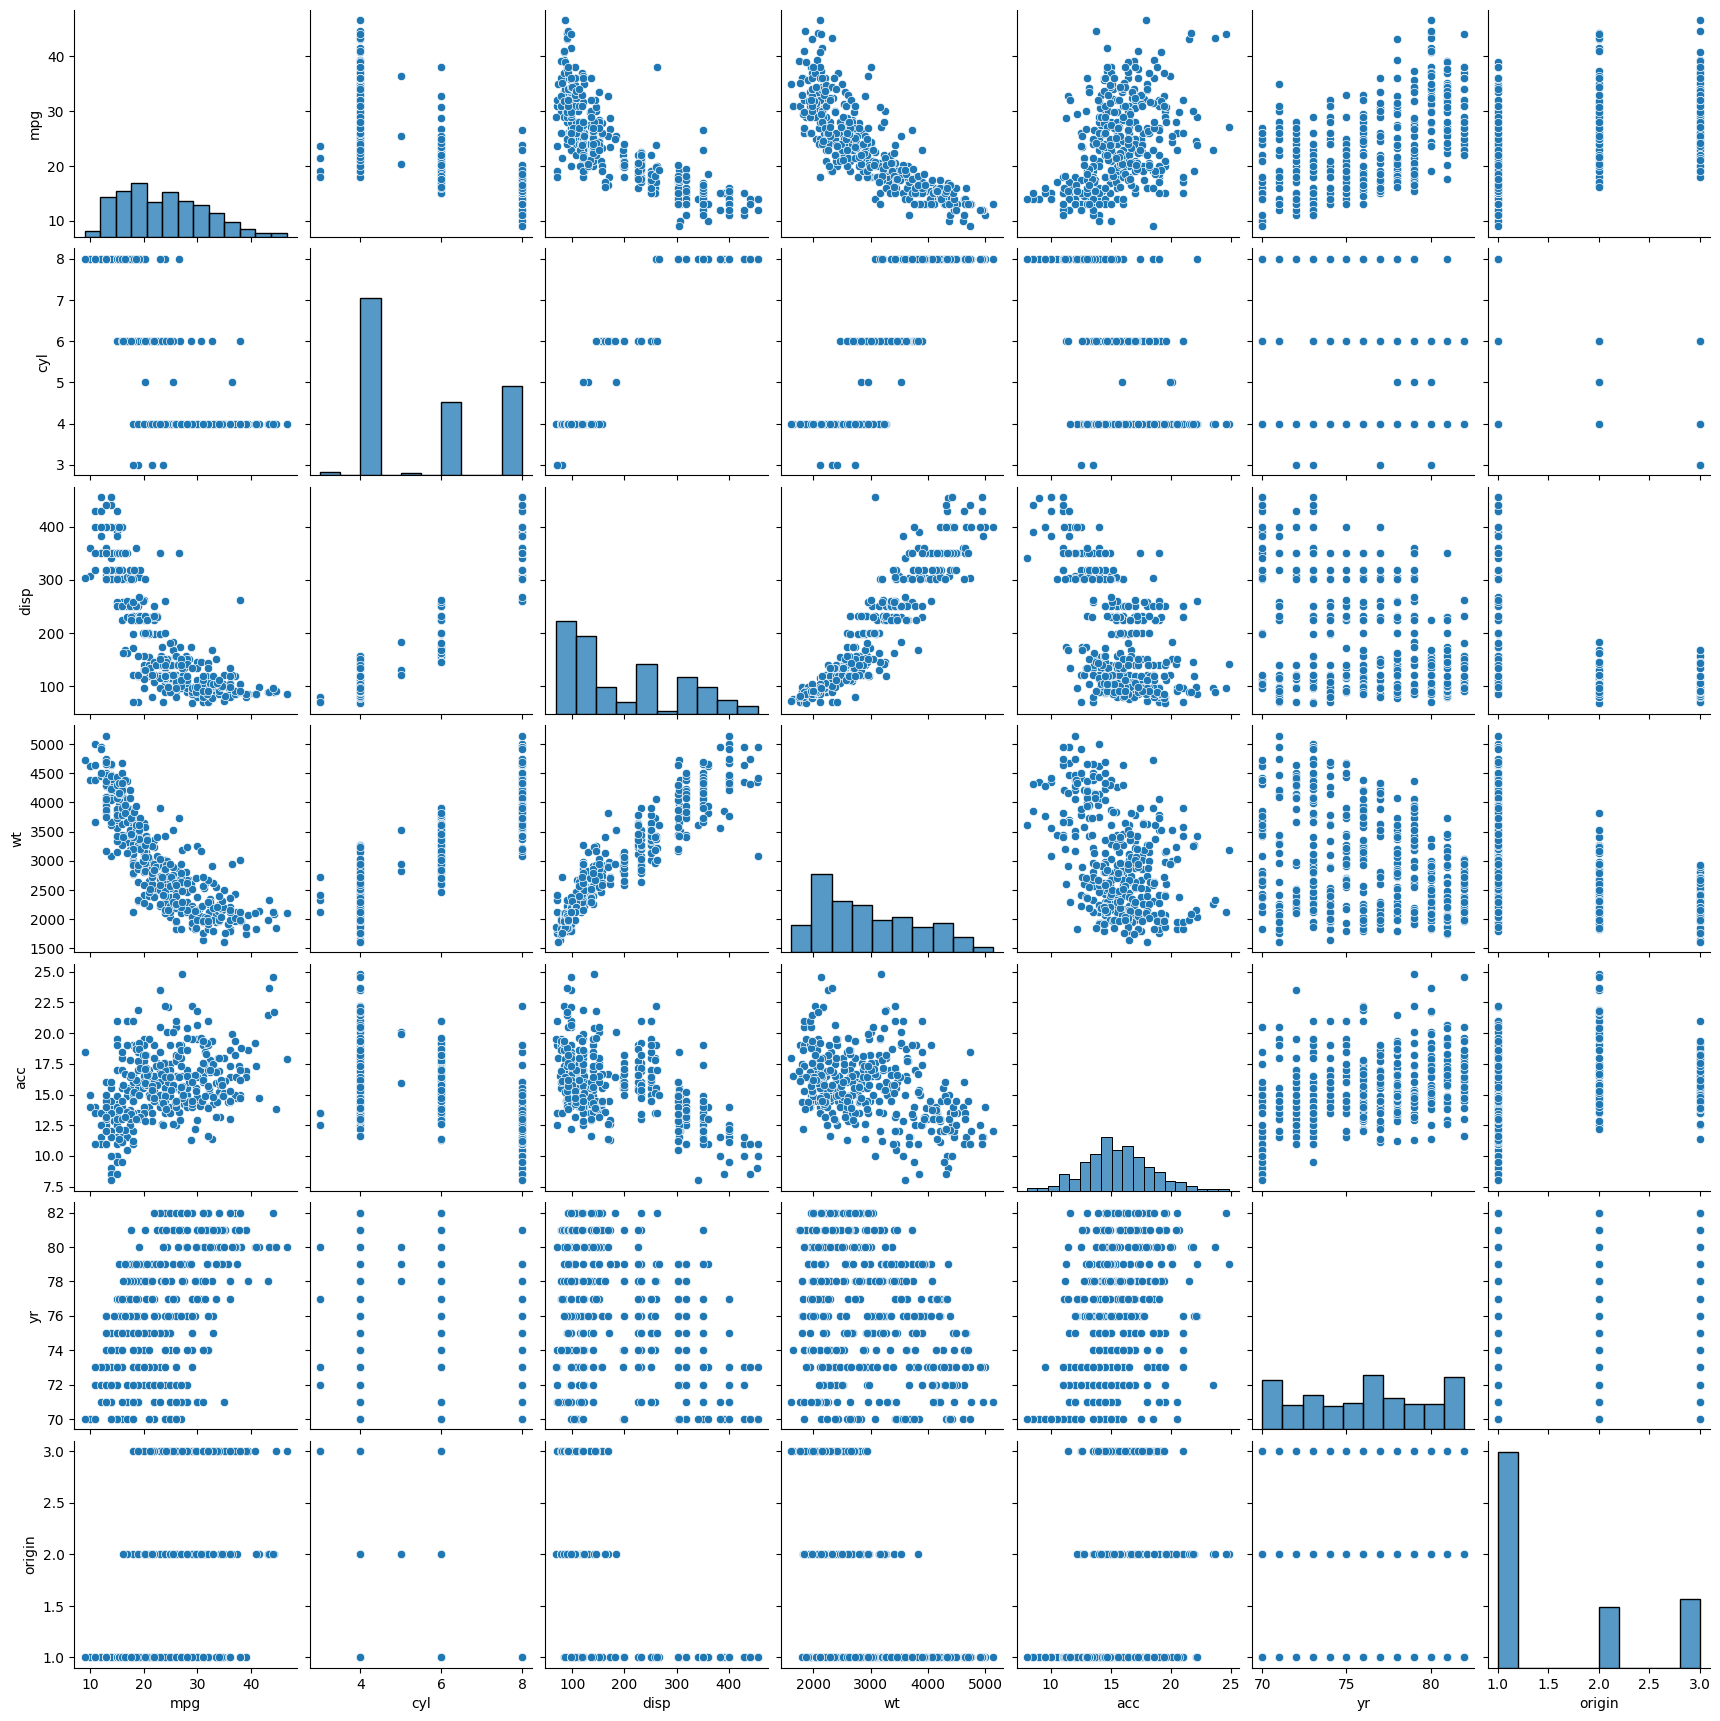

In [31]:
sns.pairplot(combined_car_df)
plt.show()

Insightes from pairplot:

- There is a negative correlation between mpg and weight, displacement, and cylinders. It proves that heavier cars with big engines and more cylinders tend to have lower fuel efficiency.
- Horsepower and acceleration seem to have a positive correlation with mpg.
- Cars with origin 1 that have lower mpg compared to cars from other origins.

**D. Visualize a scatterplot for ‘wt’ and ‘disp’. Datapoints should be distinguishable by ‘cyl’.**

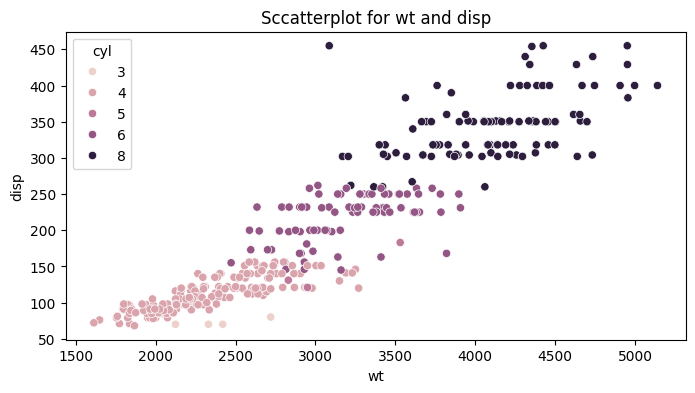

In [32]:
#Scatterplot for 'wt' and 'disp'

plt.figure(figsize=(8,4))
sns.scatterplot(x='wt', y='disp', hue='cyl', data=combined_car_df)
plt.title('Sccatterplot for wt and disp')
plt.show()

**E. Share insights for Q2.d.**

Insights:

- Cars with 8 cynliders placed in the higher points of both weight and displacement scales.
- Cars with 4 cyclinders moving towards the lower end, indicating lower weight and smaller engine.
- Cars with 6 cylinders showing moderate range of weight and displacement.
- The ScatterPlot shows a positive correlation between weight and displacement, means iof weight of car increases then its engine displacement values also increases.

**F. Visualize a scatterplot for ‘wt’ and ’mpg’. Datapoints should be distinguishable by ‘cyl’.**

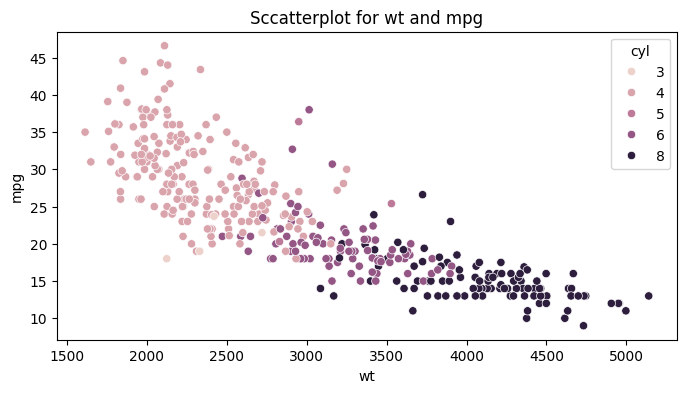

In [33]:
#Scatterplot for 'wt' and 'mpg'
plt.figure(figsize=(8,4))
sns.scatterplot(x='wt', y='mpg', hue='cyl', data=combined_car_df)
plt.title('Sccatterplot for wt and mpg')
plt.show()


**G. Share insights for Q2.f.**

Insights:

- Scatterplot showing a negative correlation between weight and mpg.
- Cars with higher numbers of cylinders seems to be heavier and less fuel effecient.
- Cars with 8 cylinders have the lowest mpg and highest weight.
- Cars with 4 cylinders have big range of mpg and weight but these cars are more fuel efficient that 6 and 8 cylinders cars.

**H. Check for unexpected values in all the features and datapoints with such values.**

In [34]:
#Checking for unexpected values in all features and datapoints
#Checking for '?' in the hp column

unexpected_values = combined_car_df[combined_car_df['hp'] == '?']
print(unexpected_values)


                 car_name   mpg  cyl   disp hp    wt   acc  yr  origin
87          ford maverick  21.0    6  200.0  ?  2875  17.0  74       1
171            ford pinto  25.0    4   98.0  ?  2046  19.0  71       1
638  renault lecar deluxe  40.9    4   85.0  ?  1835  17.3  80       2
643    ford mustang cobra  23.6    4  140.0  ?  2905  14.3  80       1
663           renault 18i  34.5    4  100.0  ?  2320  15.8  81       2
679        amc concord dl  23.0    4  151.0  ?  3035  20.5  82       1


In [36]:
#Replacing unexpected values

combined_car_df['hp'] = combined_car_df['hp'].replace('?', np.nan).astype(float)
combined_car_df['hp'].fillna(combined_car_df['hp'].mean(), inplace=True)

In [37]:
#Check for unexpected value after replacing the '?'
unexpected_values = combined_car_df[combined_car_df['hp'] == '?']
print(unexpected_values)


Empty DataFrame
Columns: [car_name, mpg, cyl, disp, hp, wt, acc, yr, origin]
Index: []


Hence, there is no unexpected values remain in the dataset.

# **3. Clustering:**

**A. Apply K-Means clustering for 2 to 10 clusters.**

In [41]:
#K-Means clustering for 2-10 clusters

#Standardizing the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(combined_car_df[['mpg', 'cyl', 'disp', 'hp', 'wt', 'acc']])

#Determining optimal number of clusters
inertias = [] #An empty list to store inertia values

for k in range(2, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_features)
  inertias.append(kmeans.inertia_)


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

**B. Plot a visual and find elbow point.**

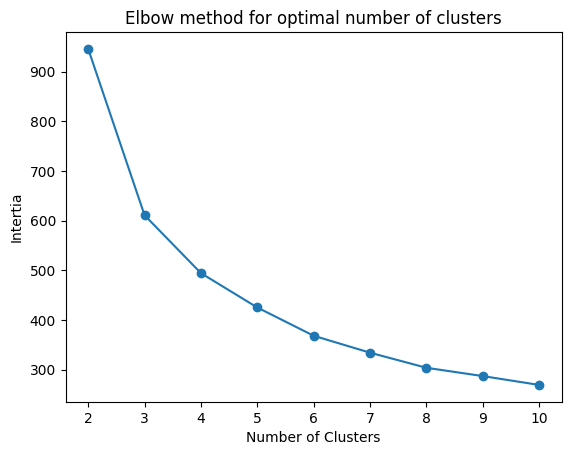

In [44]:
#plotting

plt.plot(range(2, 11), inertias, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Intertia')
plt.title('Elbow method for optimal number of clusters')
plt.show()

**C. On the above visual, highlight which are the possible Elbow points**

- As per the Plot, the elbow points can be at 3rd or 5th clusters.
- Its indicating that adding more clusters after this points doesnot reduce the inertia by significant margin.

**D. Train a K-means clustering model once again on the optimal number of clusters.**

In [47]:
#K-means clustering model

kmeans_optimal_3 = KMeans(n_clusters=3, random_state=42)
kmeans_optimal_3.fit(scaled_features)

#kmeans_optimal_5 = KMeans(n_clusters=5, random_state=42)
#kmeans_optimal_5.fit(scaled_features)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=3, random_state=42)

In [48]:
kmeans_optimal_5 = KMeans(n_clusters=5, random_state=42)
kmeans_optimal_5.fit(scaled_features)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=5, random_state=42)

**E. Add a new feature in the DataFrame which will have labels based upon cluster value.**

*Its done in the previous steps*

**F. Plot a visual and color the datapoints based upon clusters.**

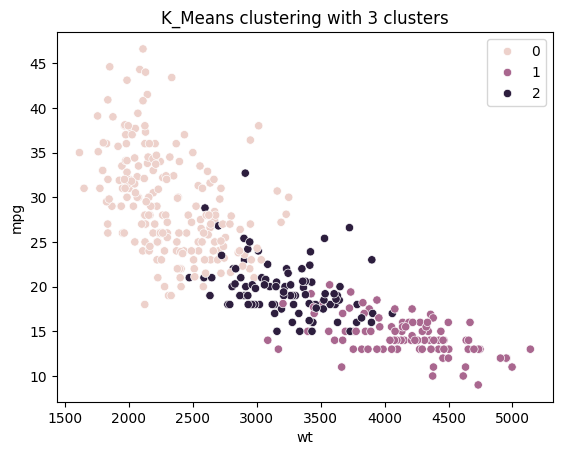

<Figure size 800x600 with 0 Axes>

In [54]:
sns.scatterplot(data=combined_car_df, x='wt', y='mpg', hue=kmeans_optimal_3.labels_)
plt.title('K_Means clustering with 3 clusters')
#plt.colorbar(scatter, label='Cluster')
plt.figure(figsize=(8, 6))
plt.show()

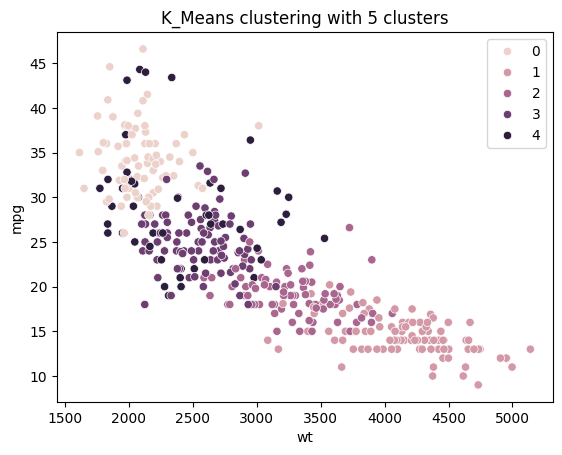

<Figure size 800x600 with 0 Axes>

In [55]:
sns.scatterplot(data=combined_car_df, x='wt', y='mpg', hue=kmeans_optimal_5.labels_)
plt.title('K_Means clustering with 5 clusters')
#plt.colorbar(scatter, label='Cluster')
plt.figure(figsize=(8, 6))
plt.show()

**G. Pass a new DataPoint and predict which cluster it belongs to.**

In [60]:
#New Data Point (Random)

new_data_point = np.array([[20, 100, 200, 25, 2900, 3]])

#Scaling new data points
new_data_point_scaled = scaler.transform(new_data_point)

#Cluster prediction for new datapoints
predicted_cluster_3 = kmeans_optimal_3.predict(new_data_point_scaled)
predicted_cluster_5 = kmeans_optimal_5.predict(new_data_point_scaled)
print('Cluster prediction for 3 clusters model:', predicted_cluster_3[0])
print('Cluster prediction for 5 clusters model:', predicted_cluster_5[0])

Cluster prediction for 3 clusters model: 1
Cluster prediction for 5 clusters model: 1


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


***Hence, with above result we got predicted cluster as 1 in both cases.***